# 🔍 Notebook 3: Filtro por Código de Proyecto — Año 25
**Plan de Compras 2025 — MINVU**

Los códigos de proyecto tienen el formato `XXXX-YY-PCZZ` donde `ZZ` son los **últimos 3 dígitos** que representan el año.  
Este notebook **filtra exclusivamente los proyectos del año 25** y realiza análisis detallados sobre ese subconjunto.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


MESES_ES = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
TC_MAP = {1:'Licitación Pública', 2:'Licitación Privada',
          3:'Contratación Directa', 4:'Convenio Marco',
          5:'Trato/Cotización Directa', 6:'Compra Ágil'}

# ── Carga y filtro ───────────────────────────────────────────
df_raw = pd.read_excel('plan_de_compras_2025.xlsx')
df_raw['Fecha de Inicio Compra'] = pd.to_datetime(df_raw['Fecha de Inicio Compra'], errors='coerce')
df_raw['Fecha Publicación PAC 2025'] = pd.to_datetime(df_raw['Fecha Publicación PAC 2025'], errors='coerce')

# Extracción del año del código de proyecto (últimos 2 dígitos tras 'PC')
df_raw['anio_codigo'] = df_raw['ID Proyecto'].str.extract(r'PC(\d{2})$')

# ═══ FILTRO AÑO 25 ═══════════════════════════════════════════
df = df_raw[df_raw['anio_codigo'] == '25'].copy()
# ═════════════════════════════════════════════════════════════

df['Tipo compra desc'] = df['Tipo compra'].map(TC_MAP).fillna(df['Tipo compra'].astype(str))
df['mes_inicio'] = df['Fecha de Inicio Compra'].dt.month
df['anio_inicio'] = df['Fecha de Inicio Compra'].dt.year
df['trimestre'] = df['Fecha de Inicio Compra'].dt.quarter

print("=" * 55)
print("  FILTRO ACTIVO: Proyectos con código año = '25'")
print("=" * 55)
print(f"  Registros totales en el archivo:  {len(df_raw):>6,}")
print(f"  Registros filtrados (PC25):       {len(df):>6,}")
print(f"  Proyectos únicos (PC25):          {df['ID Proyecto'].nunique():>6,}")
print(f"  Monto total 2025:       ${df['Monto Total Ítem Año 2025'].sum()/1e9:>8.2f} MM$")
print("=" * 55)

# Verificar el patrón de los IDs filtrados
print("\nEjemplos de IDs filtrados (PC25):")
print(df['ID Proyecto'].unique()[:10])


  FILTRO ACTIVO: Proyectos con código año = '25'
  Registros totales en el archivo:     831
  Registros filtrados (PC25):          648
  Proyectos únicos (PC25):             248
  Monto total 2025:       $   79.23 MM$

Ejemplos de IDs filtrados (PC25):
<ArrowStringArray>
[ '1583-4-PC25',  '1583-5-PC25',  '1583-6-PC25',  '1583-8-PC25',
  '1583-9-PC25', '1583-10-PC25', '1583-11-PC25', '1583-12-PC25',
 '1583-13-PC25', '1583-14-PC25']
Length: 10, dtype: str


## 1. Vista General — Año 25

In [3]:
# KPIs resumen
total_monto = df['Monto Total Ítem Año 2025'].sum()
n_proyectos = df['ID Proyecto'].nunique()
monto_prom  = df.groupby('ID Proyecto')['Monto Total Ítem Año 2025'].sum().mean()
n_unidades  = df['Unidad de Compra'].nunique()

print(f"{'KPI':40s} {'Valor':>20s}")
print("-" * 62)
print(f"{'Total Registros (filas)':40s} {len(df):>20,}")
print(f"{'Proyectos únicos':40s} {n_proyectos:>20,}")
print(f"{'Unidades de Compra':40s} {n_unidades:>20,}")
print(f"{'Monto Total Ítem 2025':40s} {'${:,.0f}'.format(total_monto):>20s}")
print(f"{'Monto Total (Miles de Millones $)':40s} {'${:.2f}B'.format(total_monto/1e9):>20s}")
print(f"{'Monto Promedio por Proyecto ($)':40s} {'${:,.0f}'.format(monto_prom):>20s}")

# Tabla pivot rápida
print("\n──── Distribución por Tipo de Proyecto ────")
tabla = df.groupby('Tipo Proyecto').agg(
    registros=('ID Proyecto', 'count'),
    proyectos=('ID Proyecto', 'nunique'),
    monto_total=('Monto Total Ítem Año 2025', 'sum')
)
tabla['monto_MM$'] = tabla['monto_total'].apply(lambda x: f"${x/1e9:.2f}B")
tabla['% registros'] = (tabla['registros'] / tabla['registros'].sum() * 100).apply(lambda x: f"{x:.1f}%")
print(tabla[['registros', 'proyectos', 'monto_MM$', '% registros']].to_string())


KPI                                                     Valor
--------------------------------------------------------------
Total Registros (filas)                                   648
Proyectos únicos                                          248
Unidades de Compra                                          1
Monto Total Ítem 2025                         $79,232,141,166
Monto Total (Miles de Millones $)                     $79.23B
Monto Promedio por Proyecto ($)                  $319,484,440

──── Distribución por Tipo de Proyecto ────
                      registros  proyectos monto_MM$ % registros
Tipo Proyecto                                                   
Proyecto estratégico         57         54    $2.26B        8.8%
Proyecto operacional        591        194   $76.97B       91.2%


## 2. Distribución — Proyectos Año 25

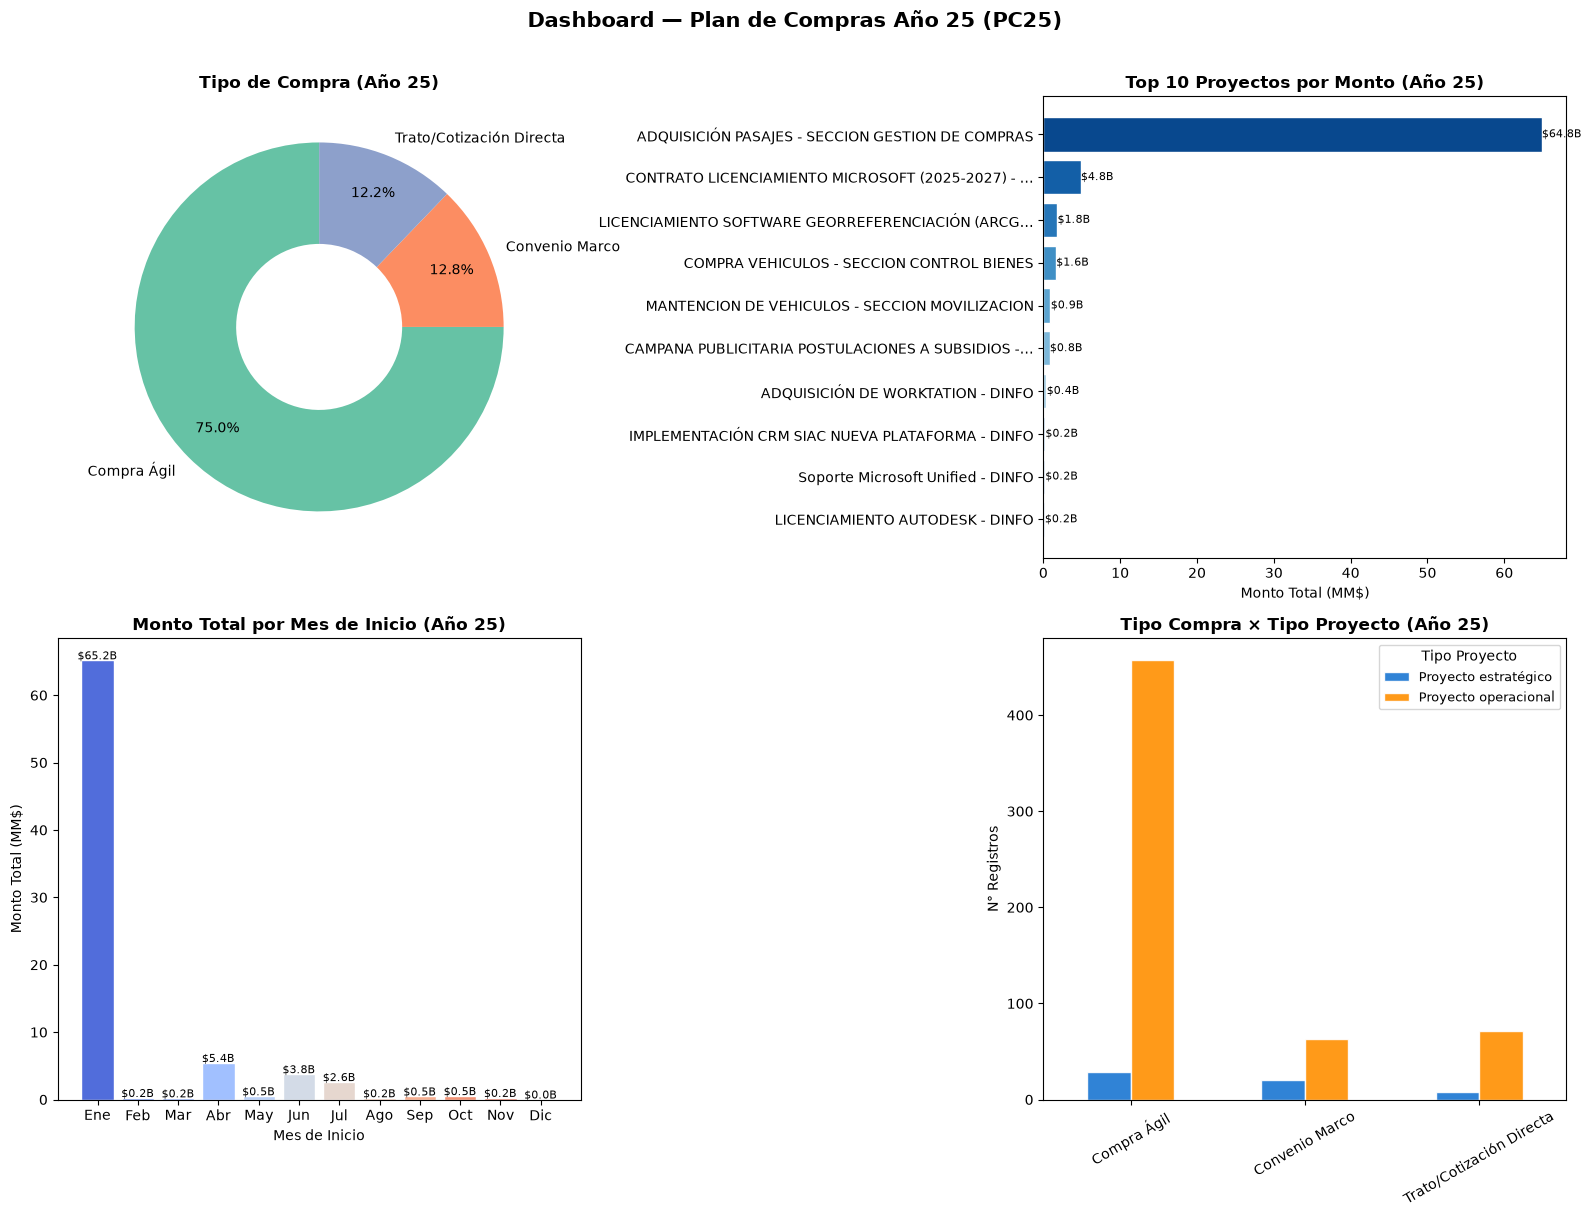

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── (a) Tipo de compra ──────────────────────────────────────
tc_cnt = df['Tipo compra desc'].value_counts()
colors_tc = sns.color_palette("Set2", len(tc_cnt))
axes[0,0].pie(tc_cnt.values, labels=tc_cnt.index, autopct='%1.1f%%',
               colors=colors_tc, startangle=90,
               pctdistance=0.78, wedgeprops=dict(width=0.55))
axes[0,0].set_title('Tipo de Compra (Año 25)', fontsize=12, fontweight='bold')

# ── (b) Top 10 proyectos por monto ─────────────────────────
top10 = (df.groupby('Nombre Proyecto')['Monto Total Ítem Año 2025']
           .sum().nlargest(10))
nombres = [n[:48] + ('…' if len(n) > 48 else '') for n in top10.index]
colores = sns.color_palette("Blues_r", 10)
bars = axes[0,1].barh(nombres[::-1], top10.values[::-1] / 1e9, color=colores[::-1], edgecolor='white')
axes[0,1].set_xlabel('Monto Total (MM$)', fontsize=10)
axes[0,1].set_title('Top 10 Proyectos por Monto (Año 25)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, top10.values[::-1]):
    axes[0,1].text(val/1e9 + 0.05, bar.get_y() + bar.get_height()/2,
                   f'${val/1e9:.1f}B', va='center', fontsize=8)

# ── (c) Monto por mes de inicio ─────────────────────────────
monto_mes = df.groupby('mes_inicio')['Monto Total Ítem Año 2025'].sum() / 1e9
meses_presentes = [MESES_ES.get(m, str(m)) for m in monto_mes.index]
colors_mes = sns.color_palette("coolwarm", len(monto_mes))
bars_m = axes[1,0].bar(meses_presentes, monto_mes.values, color=colors_mes, edgecolor='white')
axes[1,0].set_xlabel('Mes de Inicio'); axes[1,0].set_ylabel('Monto Total (MM$)')
axes[1,0].set_title('Monto Total por Mes de Inicio (Año 25)', fontsize=12, fontweight='bold')
for bar, val in zip(bars_m, monto_mes.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                   f'${val:.1f}B', ha='center', fontsize=8)

# ── (d) Tipo de proyecto × Tipo de compra ──────────────────
pivot = pd.crosstab(df['Tipo compra desc'], df['Tipo Proyecto'])
pivot.plot(kind='bar', ax=axes[1,1], color=['#1976D2', '#FF8F00'],
           edgecolor='white', alpha=0.9)
axes[1,1].set_title('Tipo Compra × Tipo Proyecto (Año 25)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('N° Registros')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Tipo Proyecto', fontsize=9)

plt.suptitle('Dashboard — Plan de Compras Año 25 (PC25)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('filtro25_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()


## 3. Top Unidades de Compra — Año 25

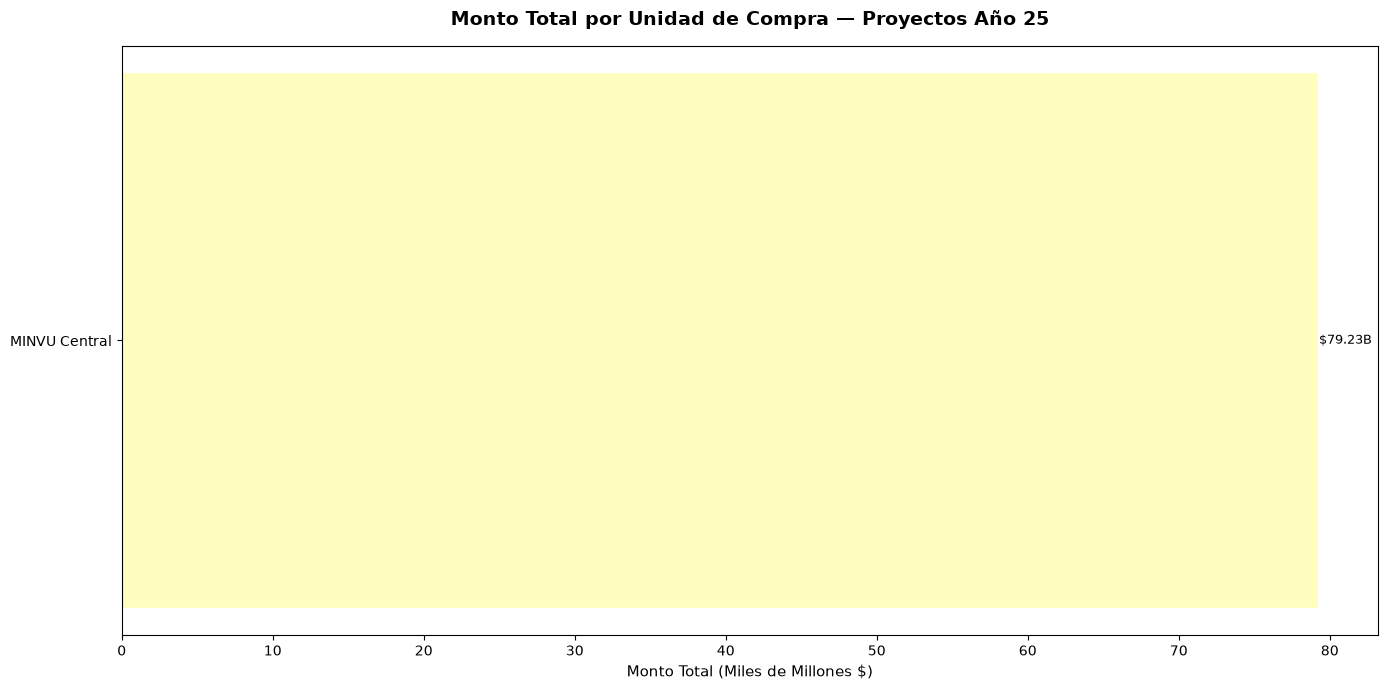


Resumen por Unidad de Compra (Top 12 — Año 25):
                                         registros  proyectos_unicos monto_MM$
Unidad de Compra                                                              
Ministerio de Vivienda y Urbanismo(766)        648               248   $79.23B


In [15]:
uc_resumen = df.groupby('Unidad de Compra').agg(
    registros=('ID Proyecto', 'count'),
    proyectos_unicos=('ID Proyecto', 'nunique'),
    monto_total=('Monto Total Ítem Año 2025', 'sum')
).sort_values('monto_total', ascending=False).head(12)
uc_resumen['monto_MM$'] = uc_resumen['monto_total'].apply(lambda x: f"${x/1e9:.2f}B")
uc_short = [u.replace('Ministerio de Vivienda y Urbanismo(766)', 'MINVU Central')
             .replace('SEREMI MINVU ', 'SEREMI ') for u in uc_resumen.index]

fig, ax = plt.subplots(figsize=(14, 7))
colores = sns.color_palette("Spectral_r", len(uc_resumen))
bars = ax.barh(uc_short[::-1], (uc_resumen['monto_total'].values / 1e9)[::-1],
               height=0.2, color=colores[::-1], edgecolor='white', linewidth=0.15)
ax.set_xlabel('Monto Total (Miles de Millones $)', fontsize=11)
ax.set_title('Monto Total por Unidad de Compra — Proyectos Año 25', fontsize=14, fontweight='bold', pad=15)
for bar, val in zip(bars, (uc_resumen['monto_total'].values / 1e9)[::-1]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}B', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('filtro25_unidades.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nResumen por Unidad de Compra (Top 12 — Año 25):")
print(uc_resumen[['registros', 'proyectos_unicos', 'monto_MM$']].to_string())


## 4. Tabla Resumen de Proyectos Únicos — Año 25

In [17]:
tabla_proy = (df.groupby(['ID Proyecto', 'Nombre Proyecto', 'Tipo Proyecto',
                           'Unidad de Compra', 'Tipo compra desc'])
                .agg(
                    n_items=('Cantidad de Ítems', 'max'),
                    monto_total_2025=('Monto Total Ítem Año 2025', 'sum'),
                    responsable=('Nombre responsable', 'first'),
                    fecha_inicio=('Fecha de Inicio Compra', 'min')
                ).reset_index()
                .sort_values('monto_total_2025', ascending=False))

tabla_proy['monto_total_2025_fmt'] = tabla_proy['monto_total_2025'].apply(lambda x: f"${x:,.0f}")
tabla_proy['unidad_corta'] = tabla_proy['Unidad de Compra'].str.replace(
    r'Ministerio de Vivienda y Urbanismo\(766\)', 'MINVU Central', regex=True
).str.replace('SEREMI MINVU ', 'SEREMI ', regex=False)

cols_mostrar = ['ID Proyecto', 'Nombre Proyecto', 'Tipo Proyecto',
                'unidad_corta', 'Tipo compra desc', 'monto_total_2025_fmt', 'fecha_inicio']
print(f"Total proyectos únicos año 25: {len(tabla_proy)}")
print()
print("Top 20 proyectos por monto total 2025:")
display_cols = ['ID Proyecto', 'Nombre Proyecto', 'Tipo Proyecto', 'monto_total_2025_fmt']
print(tabla_proy[display_cols].head(20).to_string(index=False))


Total proyectos únicos año 25: 248

Top 20 proyectos por monto total 2025:
  ID Proyecto                                                                                                           Nombre Proyecto        Tipo Proyecto monto_total_2025_fmt
1583-200-PC25                                                                          ADQUISICIÓN PASAJES - SECCION GESTION DE COMPRAS Proyecto operacional      $64,842,000,000
1583-219-PC25                                                                     CONTRATO LICENCIAMIENTO MICROSOFT (2025-2027) - DINFO Proyecto operacional       $4,839,000,000
1583-221-PC25                                                              LICENCIAMIENTO SOFTWARE GEORREFERENCIACIÓN (ARCGIS). - DINFO Proyecto operacional       $1,800,000,000
1583-193-PC25                                                                                 COMPRA VEHICULOS - SECCION CONTROL BIENES Proyecto operacional       $1,626,194,808
1583-138-PC25                      

## 5. Comparativo: Año 25 vs. Otros Años en el Dataset

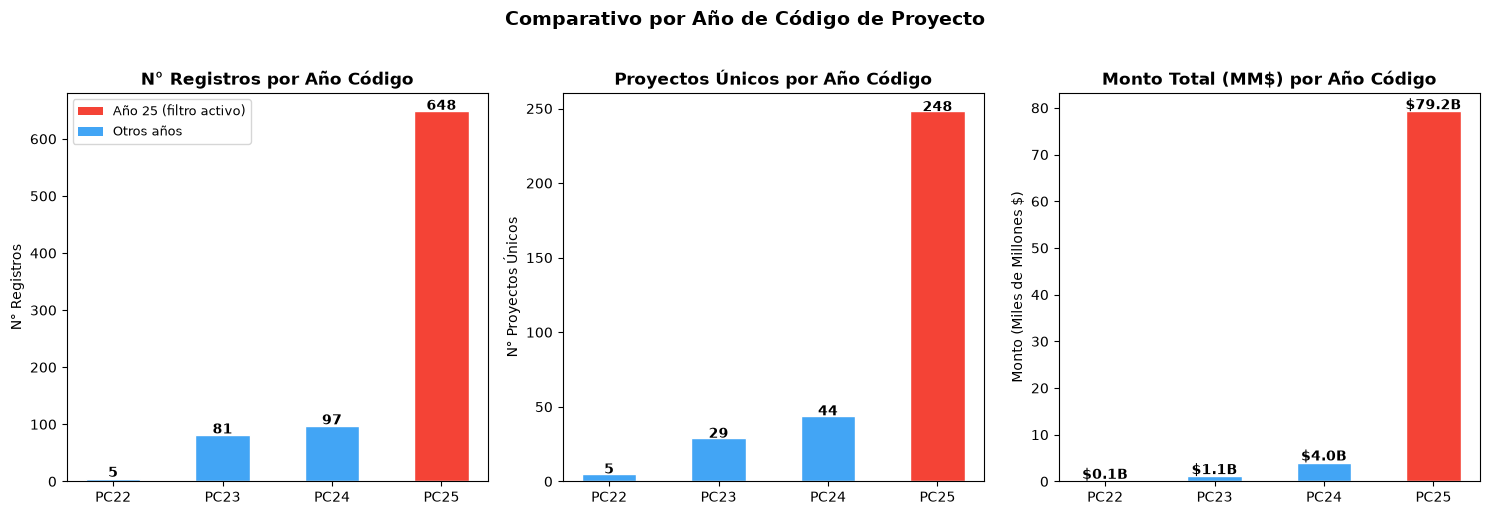

In [16]:
comp = df_raw.groupby('anio_codigo').agg(
    registros=('ID Proyecto', 'count'),
    proyectos=('ID Proyecto', 'nunique'),
    monto=('Monto Total Ítem Año 2025', 'sum')
).reset_index()
comp['anio_label'] = 'PC' + comp['anio_codigo'].fillna('?')
comp['monto_MM'] = comp['monto'] / 1e9

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = ['#42A5F5' if a != '25' else '#F44336' for a in comp['anio_codigo']]

# Registros
bars0 = axes[0].bar(comp['anio_label'], comp['registros'], color=palette, edgecolor='white', width=0.5)
axes[0].set_title('N° Registros por Año Código', fontsize=12, fontweight='bold')
axes[0].set_ylabel('N° Registros')
for bar, val in zip(bars0, comp['registros']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Proyectos únicos
bars1 = axes[1].bar(comp['anio_label'], comp['proyectos'], color=palette, edgecolor='white', width=0.5)
axes[1].set_title('Proyectos Únicos por Año Código', fontsize=12, fontweight='bold')
axes[1].set_ylabel('N° Proyectos Únicos')
for bar, val in zip(bars1, comp['proyectos']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Monto total
bars2 = axes[2].bar(comp['anio_label'], comp['monto_MM'], color=palette, edgecolor='white', width=0.5)
axes[2].set_title('Monto Total (MM$) por Año Código', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Monto (Miles de Millones $)')
for bar, val in zip(bars2, comp['monto_MM']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}B', ha='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='Año 25 (filtro activo)'),
                   Patch(facecolor='#42A5F5', label='Otros años')]
axes[0].legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.suptitle('Comparativo por Año de Código de Proyecto', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('filtro25_comparativo_anios.png', bbox_inches='tight', dpi=150)
plt.show()
